Loaded 8001 time steps.
Columns: ['step', 'time', 'resid_max', 'resid_rms', 'dil_max', 'IntDiv', 'IntAbsDiv', 'dt']


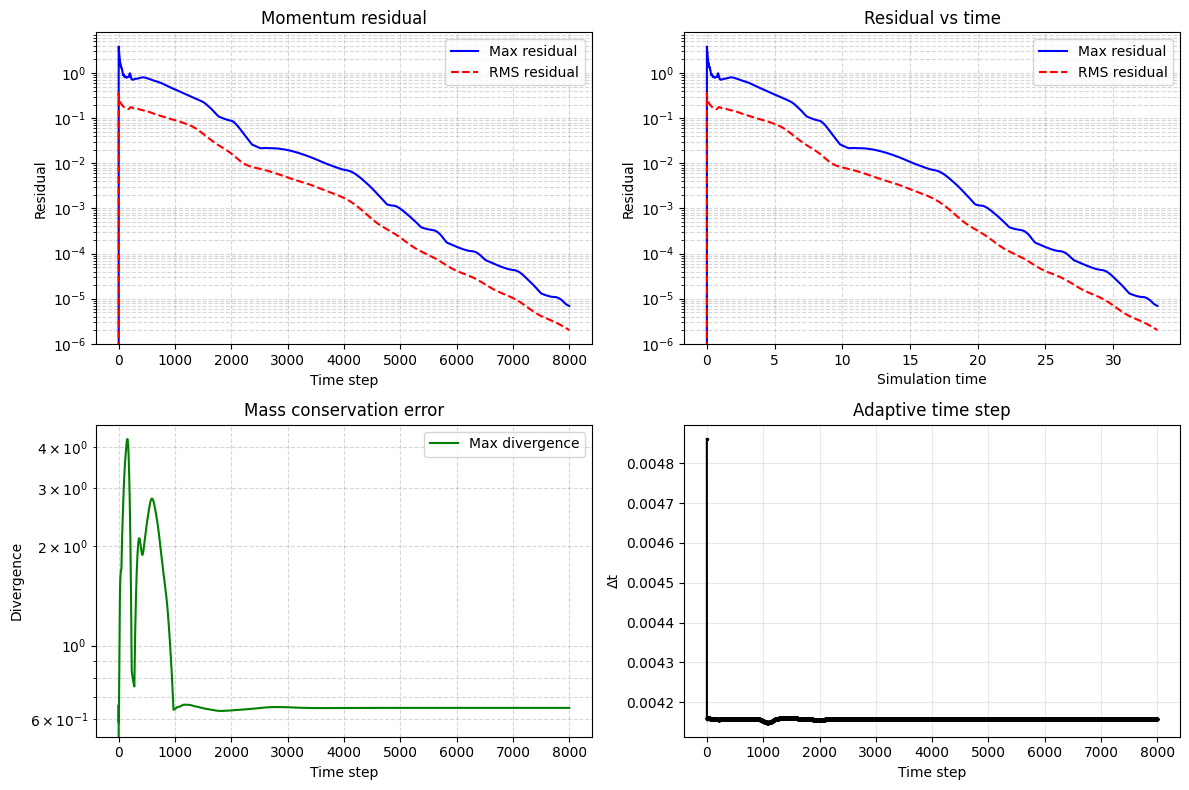


Loading snapshot: ../../results/backstep_validation/step_re100_t008000.vtk


ERROR:root:Could not find a decent config
2026-05-17 11:09:28.108 (1375.528s) [    7545A6696600]vtkXOpenGLRenderWindow.:286    ERR| vtkXOpenGLRenderWindow (0x7d9b4c0): Could not find a decent config

2026-05-17 11:09:28.110 (1375.530s) [    7545A6696600]vtkXOpenGLRenderWindow.:542   WARN| vtkXOpenGLRenderWindow (0x7d9b4c0): Could not find a decent visual

2026-05-17 11:09:28.122 (1375.542s) [    7545A6696600]vtkEGLRenderWindowInter:251   WARN| Setting an EGL display to device index: -1 require EGL_EXT_device_base EGL_EXT_platform_device EGL_EXT_platform_base extensions
2026-05-17 11:09:28.122 (1375.542s) [    7545A6696600]vtkEGLRenderWindowInter:257   WARN| Attempting to use the default egl display for the current platform...
2026-05-17 11:09:28.122 (1375.542s) [    7545A6696600]vtkEGLRenderWindowInter:263   WARN| Could not initialize a device. Exiting...
2026-05-17 11:09:28.122 (1375.542s) [    7545A6696600]vtkEGLRenderWindowInter:307   WARN| Could not set device as display. EGL_EXT_d

: 

In [4]:
# %% [markdown]
# # NavSolver Results Visualisation
# 
# This notebook plots convergence diagnostics and (optionally) visualises the final flow field.
# 
# **Requirements**: `pandas`, `matplotlib`, `numpy`, `pyvista` (for 3D plots – install with `pip install pyvista`)

# %%
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# ============================================================
# 1. CONFIGURATION – change these paths to match your run
# ============================================================
CSV_FILE = "../../results/backstep_validation/step_re100_convergence.csv" 
VTK_DIR  = "../../results/backstep_validation"            # folder containing VTK snapshots
SNAPSHOT_STEP = -1                                    # -1 = last snapshot, else step number
OUTPUT_FIGURES = True                                 # save plots as PNG

# %%
# ----------------------------------------------------------------------
# 2. LOAD CONVERGENCE DATA
# ----------------------------------------------------------------------
df = pd.read_csv(CSV_FILE)

# Rename columns for easier access (adjust if your CSV uses different names)
rename_map = {
    'ResidMax': 'resid_max',
    'ResidRMS': 'resid_rms',
    'DilMax':   'dil_max',
    'IntAbsDil': 'int_abs_dil',
    'IntDil':    'int_dil',
    'dt':       'dt',
    'step':     'step',
    'T':        'time'
}
df.rename(columns={k:v for k,v in rename_map.items() if k in df.columns}, inplace=True)

# If no 'time' column, build from cumulative dt
if 'time' not in df.columns and 'dt' in df.columns:
    df['time'] = df['dt'].cumsum()
elif 'time' not in df.columns:
    df['time'] = df['step']   # fallback

print(f"Loaded {len(df)} time steps.")
print("Columns:", list(df.columns))

# %%
# ----------------------------------------------------------------------
# 3. PLOT CONVERGENCE
# ----------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# ---- Residuals vs step ----
ax = axes[0,0]
if 'resid_max' in df:
    ax.semilogy(df['step'], df['resid_max'], 'b-', label='Max residual')
if 'resid_rms' in df:
    ax.semilogy(df['step'], df['resid_rms'], 'r--', label='RMS residual')
ax.set_xlabel('Time step')
ax.set_ylabel('Residual')
ax.set_title('Momentum residual')
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.legend()

# ---- Residuals vs time ----
ax = axes[0,1]
if 'resid_max' in df:
    ax.semilogy(df['time'], df['resid_max'], 'b-', label='Max residual')
if 'resid_rms' in df:
    ax.semilogy(df['time'], df['resid_rms'], 'r--', label='RMS residual')
ax.set_xlabel('Simulation time')
ax.set_ylabel('Residual')
ax.set_title('Residual vs time')
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.legend()

# ---- Divergence ----
ax = axes[1,0]
if 'dil_max' in df:
    ax.semilogy(df['step'], df['dil_max'], 'g-', label='Max divergence')
if 'int_abs_dil' in df:
    ax.semilogy(df['step'], df['int_abs_dil'], 'm--', label='∫|∇·u|')
ax.set_xlabel('Time step')
ax.set_ylabel('Divergence')
ax.set_title('Mass conservation error')
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.legend()

# ---- Adaptive time step ----
ax = axes[1,1]
if 'dt' in df:
    ax.plot(df['step'], df['dt'], 'k.-', markersize=3)
    ax.set_xlabel('Time step')
    ax.set_ylabel('Δt')
    ax.set_title('Adaptive time step')
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, 'No dt column found', ha='center', va='center')
    ax.set_title('Time step not available')

plt.tight_layout()
if OUTPUT_FIGURES:
    plt.savefig('convergence_plots.png', dpi=150)
plt.show()

# %%
# ----------------------------------------------------------------------
# 4. (Optional) 3D VISUALISATION OF FINAL SNAPSHOT USING PYGIST / VTK
# ----------------------------------------------------------------------
try:
    import pyvista as pv
    from pyvista import examples
    HAVE_PV = True
except ImportError:
    HAVE_PV = False
    print("\nPyVista not installed. Skipping 3D visualisation. Install with: pip install pyvista")

if HAVE_PV and VTK_DIR and os.path.isdir(VTK_DIR):
    # Find the VTK file corresponding to the requested snapshot
    vtk_files = [f for f in os.listdir(VTK_DIR) if f.endswith('.vtk')]
    if not vtk_files:
        print("No .vtk files found in", VTK_DIR)
    else:
        # Sort by step number in filename (assumes pattern like run_t000001.vtk)
        def extract_step(name):
            import re
            match = re.search(r'_t(\d+)', name)
            return int(match.group(1)) if match else 0
        vtk_files.sort(key=extract_step)
        
        if SNAPSHOT_STEP == -1:
            vtk_file = vtk_files[-1]   # last snapshot
        else:
            target = f"_t{SNAPSHOT_STEP:06d}"
            matches = [f for f in vtk_files if target in f]
            vtk_file = matches[0] if matches else vtk_files[-1]
        
        full_path = os.path.join(VTK_DIR, vtk_file)
        print(f"\nLoading snapshot: {full_path}")
        
        # Read the unstructured grid (VTK legacy format)
        grid = pv.read(full_path)
        
        # Create a plotter
        plotter = pv.Plotter(shape=(1,2), window_size=(1200, 500))
        
        # Left: velocity magnitude on a slice
        plotter.subplot(0,0)
        slice_z = grid.slice(normal='z', origin=(0,0,grid.bounds[-1]/2))
        mag = slice_z.point_data['VelocityMagnitude']
        plotter.add_mesh(slice_z, scalars=mag, cmap='coolwarm', show_edges=False,
                         scalar_bar_args={'title': 'Velocity mag'})
        plotter.add_text("Mid‑z slice", font_size=10)
        plotter.view_xy()
        
        # Right: isosurface of velocity magnitude (e.g., 0.5 * max)
        plotter.subplot(0,1)
        max_mag = grid.point_data['VelocityMagnitude'].max()
        iso = grid.contour(isosurfaces=[0.5 * max_mag], scalars='VelocityMagnitude')
        plotter.add_mesh(iso, color='red', opacity=0.7, show_edges=False)
        plotter.add_axes()
        plotter.add_text("Isosurface Vmag = 0.5·max", font_size=10)
        
        plotter.show(screenshot='flow_field.png' if OUTPUT_FIGURES else None)
else:
    print("VTK visualisation skipped – install pyvista and provide VTK_DIR")

# %%
# ----------------------------------------------------------------------
# 5. PRINT FINAL STATISTICS
# ----------------------------------------------------------------------
if len(df) > 0:
    last = df.iloc[-1]
    print("\n=== Final convergence statistics ===")
    print(f"Step           : {last.get('step', 'N/A')}")
    print(f"Time           : {last.get('time', 'N/A'):.6f}")
    print(f"ResidMax       : {last.get('resid_max', 'N/A'):.3e}")
    print(f"ResidRMS       : {last.get('resid_rms', 'N/A'):.3e}")
    print(f"DilMax         : {last.get('dil_max', 'N/A'):.3e}")
    print(f"Δt (final)     : {last.get('dt', 'N/A'):.6f}")

In [3]:
import pyvista as pv
from pathlib import Path

directory = Path("../../results/cam_re960")  # <-- change to your directory

for vtk_file in directory.glob("*.vtk"):

    mesh = pv.read(vtk_file)

    output = vtk_file.with_suffix(".vti")

    mesh.save(output)

    print(f"Saved {output}")

from pathlib import Path

directory = Path("../../results/cam_re960")

files = sorted(directory.glob("*.vti"))

with open(directory / "cam_re960.pvd", "w") as f:

    f.write("""<?xml version="1.0"?>
<VTKFile type="Collection" version="0.1" byte_order="LittleEndian">
  <Collection>
""")

    for file in files:

        # Extract timestep from filename
        timestep = file.stem.split("_t")[-1]

        f.write(
            f'    <DataSet timestep="{int(timestep)}" '
            f'file="{file.name}"/>\n'
        )

    f.write("""  </Collection>
</VTKFile>
""")

print("Generated cam_re960.pvd")

Saved ../../results/cam_re960/cam_re960_t006800.vti
Saved ../../results/cam_re960/cam_re960_t005200.vti
Saved ../../results/cam_re960/cam_re960_t004000.vti
Saved ../../results/cam_re960/cam_re960_t001600.vti
Saved ../../results/cam_re960/cam_re960_t003200.vti
Saved ../../results/cam_re960/cam_re960_t005400.vti
Saved ../../results/cam_re960/cam_re960_t001400.vti
Saved ../../results/cam_re960/cam_re960_t002200.vti
Saved ../../results/cam_re960/cam_re960_t008200.vti
Saved ../../results/cam_re960/cam_re960_t006200.vti
Saved ../../results/cam_re960/cam_re960_t009200.vti
Saved ../../results/cam_re960/cam_re960_t005800.vti
Saved ../../results/cam_re960/cam_re960_t004800.vti
Saved ../../results/cam_re960/cam_re960_t000200.vti
Saved ../../results/cam_re960/cam_re960_t003400.vti
Saved ../../results/cam_re960/cam_re960_t002400.vti
Saved ../../results/cam_re960/cam_re960_t002000.vti
Saved ../../results/cam_re960/cam_re960_t006600.vti
Saved ../../results/cam_re960/cam_re960_t004600.vti
Saved ../../